<a href="https://colab.research.google.com/github/nishta2005/cognicare/blob/main/LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv('/content/train_preprocessed.csv')

cols_to_drop = [
    'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL',
    'CholesterolHDL', 'CholesterolTriglycerides',
    'Hypertension', 'DietQuality', 'SleepQuality',
    'AlcoholConsumption', 'Smoking'
]

df = df.drop(columns=cols_to_drop)

df.to_csv('alzheimers_reduced.csv', index=False)

print(f"Done! Shape: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Done! Shape: (2222, 23)
Remaining columns: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'PhysicalActivity', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'SystolicBP', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']


In [3]:
from google.colab import files
files.download('alzheimers_reduced.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import pandas as pd
df = pd.read_csv('/content/alzheimers_reduced.csv')
print(df.head(), df['Diagnosis'].value_counts())

   Age  Gender  Ethnicity  EducationLevel       BMI  PhysicalActivity  \
0   86       0          2               1  0.065466          0.571099   
1   62       1          0               3  0.070065         -1.050032   
2   75       0          0               0 -0.316941          1.628134   
3   89       0          0               0 -0.567289         -1.257326   
4   76       1          0               2  1.533521          1.188813   

   FamilyHistoryAlzheimers  CardiovascularDisease  Diabetes  Depression  ...  \
0                        1                      0         0           0  ...   
1                        0                      0         0           0  ...   
2                        0                      1         1           1  ...   
3                        0                      0         0           0  ...   
4                        0                      0         1           0  ...   

   FunctionalAssessment  MemoryComplaints  BehavioralProblems       ADL  \
0    

In [6]:
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

df.dropna(inplace=True)
le = LabelEncoder()
df['Diagnosis'] = le.fit_transform(df['Diagnosis'])

X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X,y)

In [9]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(X_res,y_res, test_size=0.2, random_state = 42)

model = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['mild', 'moderate']))

[LightGBM] [Info] Number of positive: 907, number of negative: 870
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1432
[LightGBM] [Info] Number of data points in the train set: 1777, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.510411 -> initscore=0.041649
[LightGBM] [Info] Start training from score 0.041649
              precision    recall  f1-score   support

        mild       0.95      0.94      0.95       241
    moderate       0.93      0.94      0.94       204

    accuracy                           0.94       445
   macro avg       0.94      0.94      0.94       445
weighted avg       0.94      0.94      0.94       445



In [8]:
print(df['Diagnosis'].value_counts())  # Check original data before encoding

Diagnosis
0    1111
1    1111
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


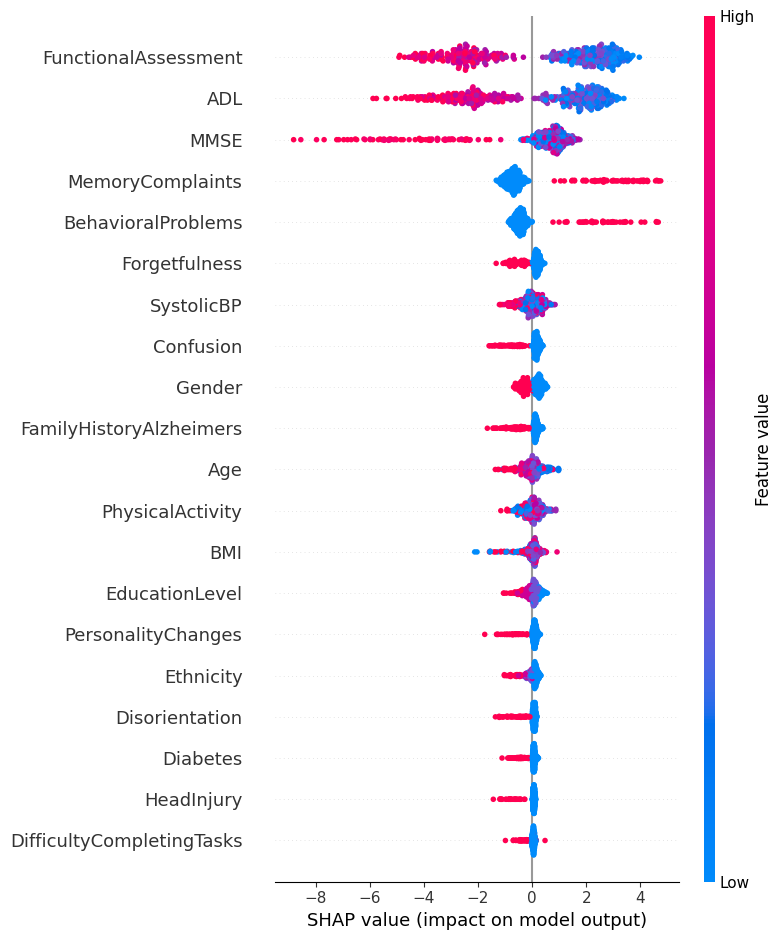

In [10]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

Tree Explainer is for tree based ml models like lightgbm
Summary plot will generate a chart showing which features matter most overall - mmse score tops the chart


SHAP = SHapely Additive exPlanations
what ml models do is classify/give you a prediction but dont give you a reason
SHAP solves this
for every single prediction SHAP calculates how much each feature is contributed to that specific prediction



In [12]:
import joblib
joblib.dump(model, 'cognicare_lightgbm.pkl')
joblib.dump(le,'label_encoder.pkl')
from google.colab import files
files.download('cognicare_lightgbm.pkl')
files.download('label_encoder.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

what joblib does is saves your ml model as a file on your pc
label encoder converts the predictions given by the ml model ie 0,1 in this case to 'mild' or 'moderate' respectively.